# Baseline & первые эксперименты

Этап 1: baseline (логистическая регрессия) + быстрый бенчмарк нескольких моделей. Глубокий тюнинг и финальные модели - этап 2.

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.preprocessing import CLASS_LABELS, prepare_data
from src.modeling import (
    benchmark_models,
    confusion,
    detailed_report,
    evaluate,
    get_baseline_model,
    save_model,
    train_and_score,
)

sns.set_theme(style="whitegrid", context="notebook")

## 1. Подготовка данных

Стратифицированный сплит 70/15/15 (train/val/test). Внутри пайплайна делается impute (median / most_frequent) + scaling + OHE для категориальных.

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(random_state=42)
print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)
print("features:", list(X_train.columns))
print()
print("class balance (train):")
print(y_train.value_counts(normalize=True).round(3))

train: (2496, 15) val: (535, 15) test: (535, 15)
features: ['PeriodDays', 'SemiMajorAxisAU', 'Eccentricity', 'InclinationDeg', 'HostStarMassSlrMass', 'HostStarRadiusSlrRad', 'HostStarMetallicity', 'HostStarTempK', 'DistFromSunParsec', 'DiscoveryYear', 'LogPeriodDays', 'LogSemiMajorAxisAU', 'LogDistFromSunParsec', 'EquilibriumProxy', 'DiscoveryMethod']

class balance (train):
PlanetClass
neptunian      0.348
terrestrial    0.342
gas_giant      0.310
Name: proportion, dtype: float64


## 2. Baseline - Logistic Regression

Простая модель, без feature engineering за пределами уже добавленных лог-преобразований и `EquilibriumProxy`

In [10]:
baseline = get_baseline_model()
scores = train_and_score(baseline, X_train, y_train, X_val, y_val)
pd.Series(scores).to_frame("baseline_logreg")

,baseline_logreg
train_accuracy,0.661058
train_f1_macro,0.668824
val_accuracy,0.680374
val_f1_macro,0.688862
val_f1_weighted,0.685306


In [11]:
print(detailed_report(baseline, X_val, y_val))

              precision    recall  f1-score   support

   gas_giant     0.8939    0.7108    0.7919       166
   neptunian     0.6224    0.6559    0.6387       186
 terrestrial     0.5990    0.6776    0.6359       183

    accuracy                         0.6804       535
   macro avg     0.7051    0.6815    0.6889       535
weighted avg     0.6987    0.6804    0.6853       535



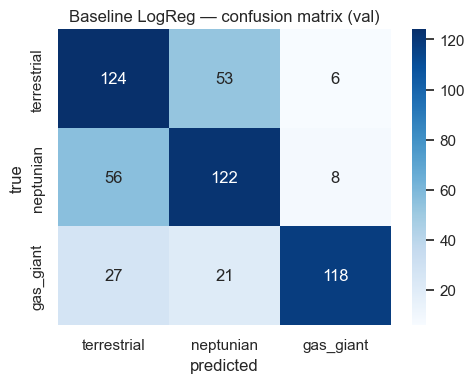

In [ ]:
cm = confusion(baseline, X_val, y_val, labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Baseline LogReg - confusion matrix (val)")
plt.tight_layout()
plt.show()

## 3. Бенчмарк нескольких моделей

Этап 1 - точка отсчёта. Глубокий тюнинг - этап 2

In [13]:
bench = benchmark_models(X_train, y_train, X_val, y_val).round(4)
bench

,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,val_f1_weighted
model,,,,,
knn,0.7276,0.7343,0.7159,0.7238,0.7200
random_forest,1.0000,1.0000,0.6935,0.7001,0.6947
logreg,0.6611,0.6688,0.6804,0.6889,0.6853


## 4. Оценка baseline на test и сохранение модели

Test-сплит используется один раз - для финальной оценки baseline. Дальнейшие эксперименты этапа 2 не должны его подсматривать

In [14]:
test_metrics = evaluate(baseline, X_test, y_test)
print("baseline test metrics:", test_metrics)
saved = save_model(baseline, "baseline_logreg.joblib")
print("model saved to:", saved)

baseline test metrics: {'accuracy': 0.6990654205607477, 'f1_macro': 0.703969571644493, 'f1_weighted': 0.6994513757443362}
model saved to: /Users/georgepust/Desktop/university/3/ml/project/hseml-group-project-vivatttt/models/baseline_logreg.joblib
